In [1]:
from IPython.display import Image

# 제5장. (지역) 특성 

### Top-down 접근 vs Bottom-up 접근 

- Top-down : 이미지를 (물체) 영역으로 나누고, 각 물체를 인식.
- Bottom-up: 이미지에서 눈에 띄는 위치 (랜드마크)를 찾고 이를 통하여 물체를 인식하고, 나아기 이미지 전체를 파학


### 특징의 종류

- 에지 특성: 에지의 세기, 방향, 연결 정도 등  
- 영역 특성: 형태 특성 (Hu-moment), 영역의 Texture (컬러값)의 특성 (분산, 엔트로피 등)   
- **(지역)특성**:  한 화소점을 중심으로 하는 화소값의 변화 특성
    - feature (특징)라고 표현 하면 주로 feature point (특징점)을 의미함. 
 
### 응용

- 하나의 대상을 촬영한 두개 또는 여러개의 이미지에서 대응되는 위치 찾아냄: 카메라 위치/이동 추정, 이미지 스티칭   
- 특징들을 통한 물제 인식: 분류 알고리즘과 함께 사용 




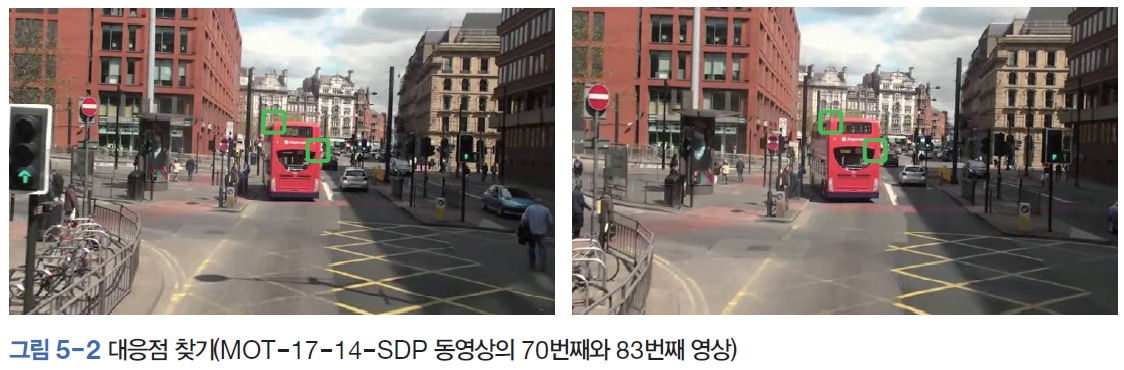

In [2]:
Image("그림 5-2.jpg", width=1024)

## 1. 발상  

####  인간이 어떤 곳을 설명이나 약도를 보고 찾아서 갈 때, 인식이 잘되는 특별한 랜드마크 장소를 인식하면서 가는 것과 유사함.
    - **공릉역1번출구**로 나와  **덩킨 도너츠 모퉁이**에서 위쪽으로 이동하다가 **서브웨이**를 만나면 좌회전을 해서 바로 있는 **건널목**에서 건너면 서울과기대 쪽문이 나와.
    - 이런 랜드 마크는 일반적이지 않은 상점과 위치 (코너)를 가지고 있음.   
    
#### 초창기의 연구 

- 코너를 찾기 위하여 노력 (코너는 edge 중에 특수한 위치) 
- 물체의 실제 모퉁이 보다 반복성을 더 중요하게 취급하는 발상의 전환

#### 바람직한 특징점의 조건

- 특징점 추출의 특성 
    - **반복성 (Repeatability)**: 조명이나 각도, 거리, 방향 등이  변해도 같은 지점이라면 동일한 특징점으로 다시 검출되어야 함.
    - **지역성 (Locality)**: 특징이 이미지의 좁은 영역에 집중되어 있어, 일부가 가려지거나 배경이 변해도 전체 매칭에 영향을 주지 않아야 함.
    - **적당한 양 (Quantity)**: 너무 적으면 물체를 인식하기 어렵고, 너무 많으면 계산량이 폭증하므로 목적에 맞는 적절한 개수가 검출되어야 함.

- 특징 기술자의 특징 
    - **불변성 (Invariance)**: 이미지가 회전하거나 크기가 변하더라도 특징 자체의 값(기술자)은 변하지 않고 유지되어야 함.
    - **분별력 (Discriminating Power)**: 서로 다른 지점의 특징은 확연히 구분되어야 하며, 이를 통해 서로 매칭될 확률을 높음.

- 공통 특성 
    - **계산 효율 (Efficiency)***: 실시간 시스템이나 모바일 기기에서도 빠르게 검출하고 비교할 수 있을 만큼 연산 속도가 충분히 빨라야 함. 
** 주의 ** 이들 조건은 상충 관계 응용에 따라 적절히 조절할 필요

###  인지 실험

 - 왼쪽 영상의 a, b, c 중에 어느 것이 오른쪽 영상에서 찾기 쉬울까?
 - a가 가장 쉽고 c가 가장 어려움. 왜?


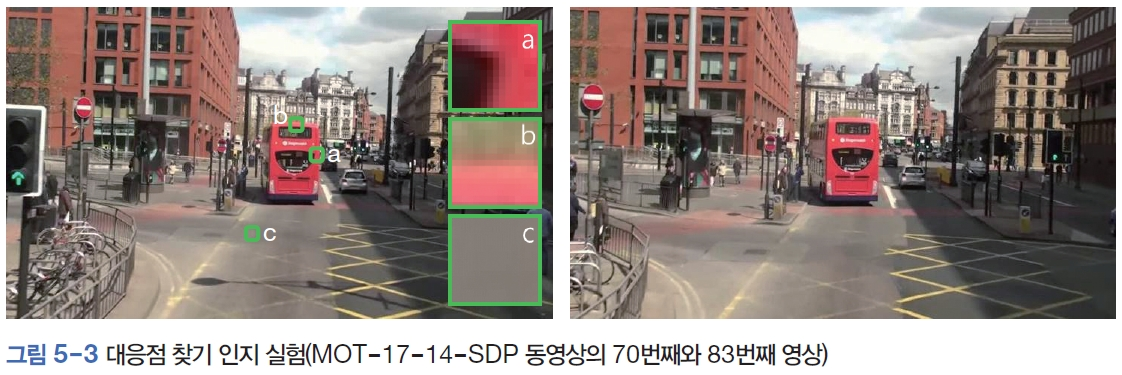

In [5]:
Image("그림 5-3.jpg", width=1024)

## 2. Morabec의  해석 

-  a는 여러 방향으로 색상 변화가 있어 찾기 쉬운데 c는 어느 방향으로도 미세한 변화만 있어 찾기 어려움

-  (y_0, x_0) 위치가 얼마나 눈에 잘띄는지 에 대한 정도 (S)를 여러 (4/8) 방향 $(v, u)$의 변화를 측정 
    - 주변화소와의 값 차이가 크면 눈에 잘 띰: 차의 제곱
    - 해당 위치에서만 계산하는 대신 주면 영역을 차이를 합  (일반적으로 $h = 1, w = 1$을 사용) 
    
    - $  S(y_0, x_0) = \sum_{ y_0 - h < y < y_0 + h} \sum_{ x_0 -w < x < x_0 +w  } (I(y+v, x+u) - I(y, x))^2  $
    

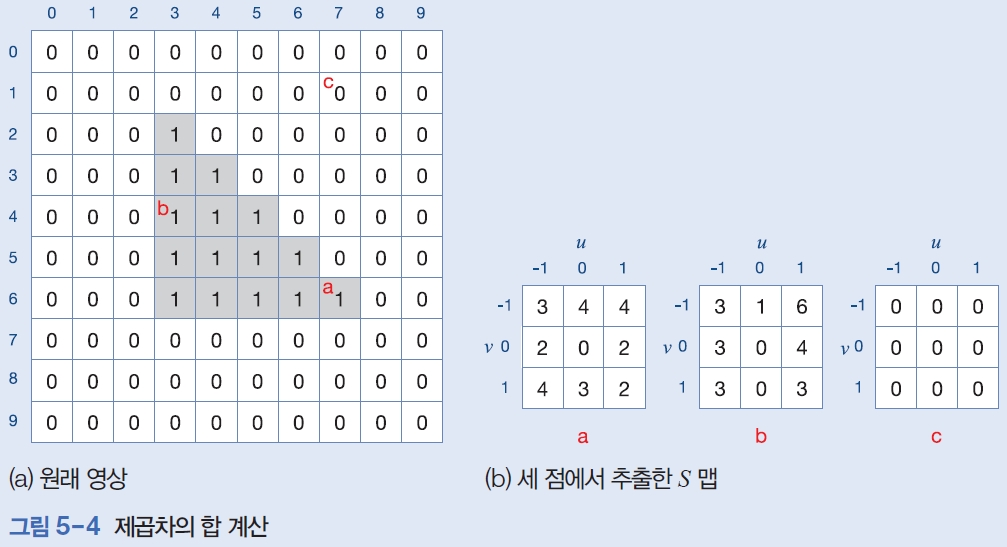

In [10]:
Image("그림 5-4.jpg", width=720)

- 결과 설명 
    - c는 모든 방향에서 변화가 없어 S 맵의 모든 요소가 0. 지역 특징으로 자격이 없음
    - b는 수평 방향만 변화가 있어 S 맵의 좌우 이웃만 큰 값. 지역 특징으로 부족
    - a는 모든 방향으로 변화가 있어 S 맵에서 8이웃 모두 큰 값. 지역 특징으로 훌륭함

- 모라벡은 S 맵에서 상하좌우 네 이웃 화소의 최소값을 기준으로 정의함.

  - $ C = min (S(-1,0), S(1, 0), S (0, +1), S(0, -1)) $
    
    


## 3. Harris (corner) detector

- 모라벡의 결과를 이론적으로 확장 

    - 2차 모멘트 행렬을 통한 특징점 검출
    - 잡음에 대처하기 위해 가우시안 적용하여 가중치 제곱차의 합으로 정의 
    
      $$ S(v,u)= \sum_{y}  \sum_{x}  G(y, x) (I(y + v, x + u) −  I(y, x)))^2 $  at $(y_0, x_0)$, $(y, x) = N(y_0, x_0)$$

    -  테일러 확장
         - $ I(y +v, x + u) ~ I(y, x) + v I'_y (y,x) + u I'_x (y, x) $  을 대입

      $$ S(v,u)= \sum_{y}  \sum_{x}  G(y, x) (v I'_y (y,x) + u I'_x (y, x))^2 $$
    


- 이를 다음과 같이 벡터 관계식으로 전개  

 $$ S(v, u) \cong \sum_{y} \sum_{x} G(y, x) (v d_y + u d_x)^2 = \sum_{y} \sum_{x} G(y, x) (v^2 d_y^2 + 2 v u d_y d_x + u^2 d_x^2)$$
 
    - 첫 번째 단계: 합산 기호 안에서 벡터와 행렬의 곱으로 표현     
$$= \sum_{y} \sum_{x} G(y, x) \begin{pmatrix} v & u \end{pmatrix} \begin{pmatrix} d_y^2 & d_y d_x \\ d_y d_x & d_x^2 \end{pmatrix}        \begin{pmatrix} v \\ u \end{pmatrix} $$
    - 두 번째 단계: 변위 벡터 $(v, u)$를 합산 기호 밖으로 추출

$$= \begin{pmatrix} v & u \end{pmatrix} \sum_{y} \sum_{x} G(y, x) \begin{pmatrix} d_y^2 & d_y d_x \\ d_y d_x & d_x^2 \end{pmatrix} \begin{pmatrix} v \\ u \end{pmatrix}$$

   - 세 번째 단계: 가중치 $G(y, x)$를 행렬 내부의 각 요소에 적용하여 최종 구조 완성

$$= \begin{pmatrix} v & u \end{pmatrix} \begin{bmatrix} \sum_{y} \sum_{x} G(y, x) d_y^2 & \sum_{y} \sum_{x} G(y, x) d_y d_x \\ \sum_{y} \sum_{x} G(y, x) d_y d_x & \sum_{y} \sum_{x} G(y, x) d_x^2 \end{bmatrix} \begin{pmatrix} v \\ u \end{pmatrix}$$

- 해리스 코너 공식 

$$S(v, u) \cong \begin{pmatrix} v & u \end{pmatrix} \begin{pmatrix} G \circledast d_y^2 & G \circledast d_y d_x \\ G \circledast d_y d_x & G \circledast d_x^2 \end{pmatrix} \begin{pmatrix} v \\ u \end{pmatrix} = \mathbf{u} \mathbf{A} \mathbf{u}^\text{T} \quad (5.6)$$

    - 여기서 A 행렬을 코너 메트릭스라고 함 
$$\mathbf{A} = \begin{pmatrix} G \circledast d_y^2 & G \circledast d_y d_x \\ G \circledast d_y d_x & G \circledast d_x^2 \end{pmatrix}  = \begin{pmatrix} p & r \\ r & q \end{pmatrix} $$


- 코너 Response 함수 

$$C = \lambda_1 \lambda_2 - k(\lambda_1 + \lambda_2)^2 = (pq - r^2) - k(p + q)^2 $$
    - k 값은 0.04 (~ 0.06)을 사용 

    - 여기서 eigen values와 행렬의 trace, 디터미넌트 관계를 사용하여 eignen value 계산 없이 바로 행렬값에에서 계산이 가능 
    
- ** Note **
   - Hessian 매트릭스의 eigenvalue와 curvature 관련된 이론
   - Harris Corner matrix M은 유사하지만 Hessian이 아니고 대칭 메트릭스가 eigen value는 모두 양수임
       - 아래 그림에서 saddle point 안생김. 위로 볼록도 안생김 (아래로볼록만 생김)     
   - 참고: https://youtu.be/IUK8mvqNeYw

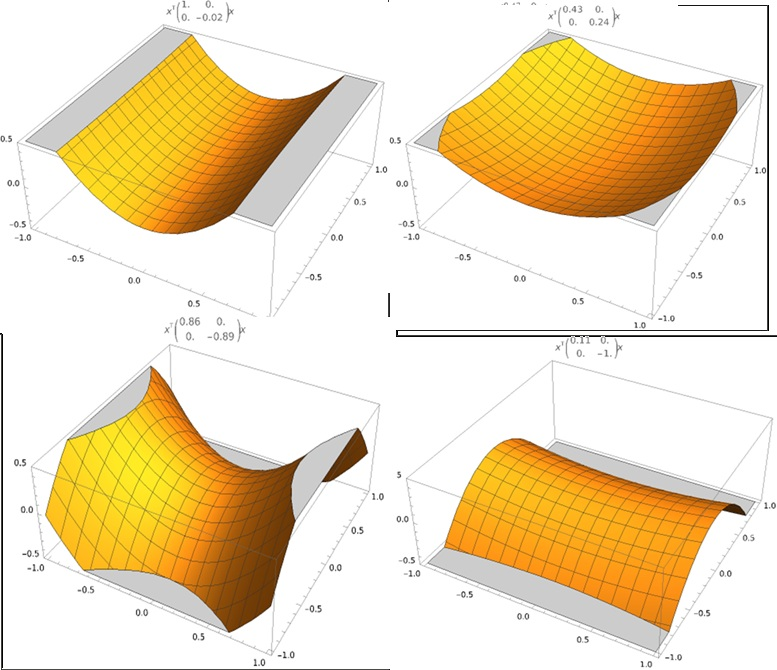

In [5]:
Image("curvature.jpg", width=640)

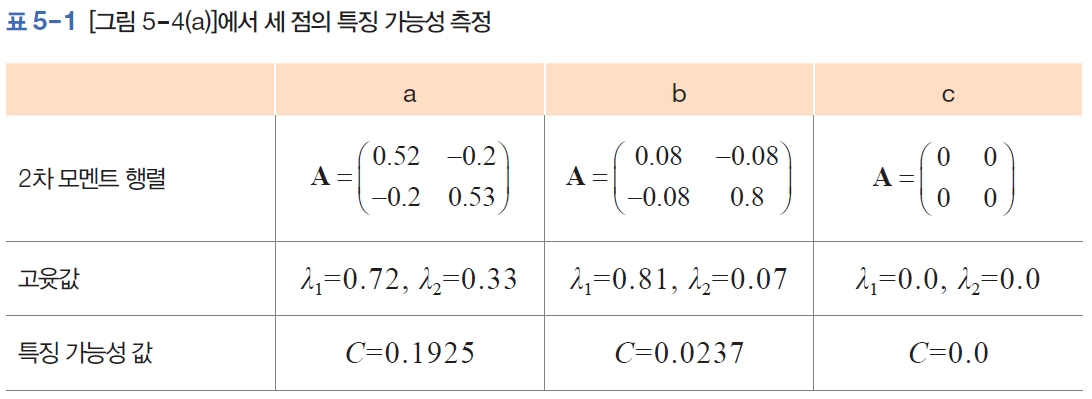

In [13]:
Image("표 5-1.jpg", width=720)

###  해석
 -  고유치 두개가 모두 크면 (양 또는 음의 blob),  C > 0.04 
 -  고유치 하나만 크면 (에지) C < 0.04 
 -  고유치 둘다 작으면 (평탄) C << 0.04

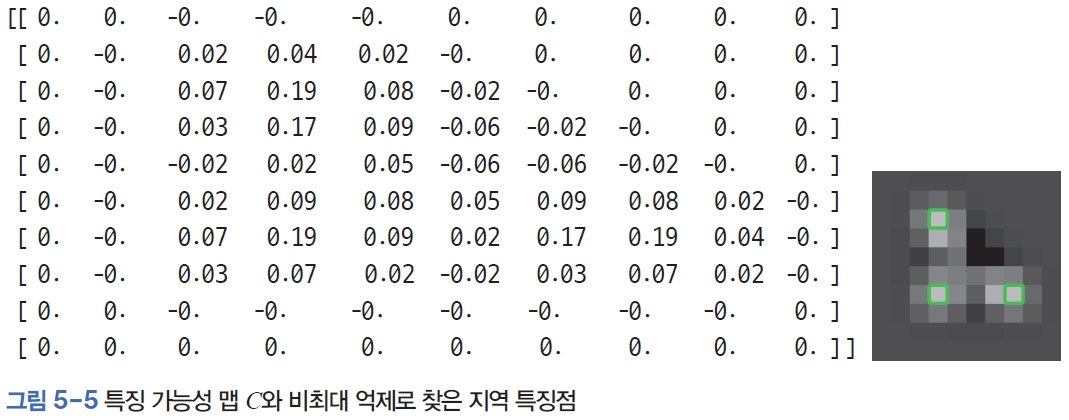

In [2]:
Image("그림 5-5.jpg", width=640)

### 해리스코너의 특징 

- 물체의 실제 모퉁이 뿐 아니라 블롭에서도 검출
- 이후에는 모퉁이 대신 특징점feature point 또는 관심점interest point으로 부름
- 이동과 회전에 불변 (찾아짐)
- 스케일에는 불변 아님 (계산 window의 크기)


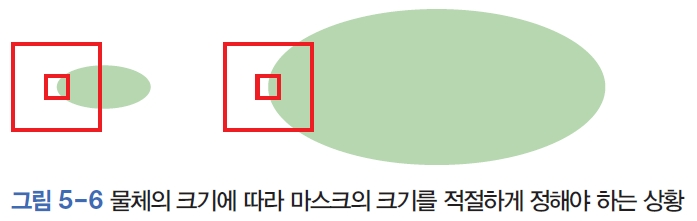

In [16]:
Image("그림 5-6.jpg", width=720)

## OpenCV harris corner 

 - resonse = cv2.cornerHarris(src, blockSize, ksize, k)
     - blockSize: gradient 합산을 위한 window 크기 
     - ksize: gradient 계산을 위한 소벨 연산자 크기
     - k:reponse 공식의 k 값
     - return:  reponse 값 

(<Axes: title={'center': 'response'}>,
 (-0.5, 117.5, 188.5, -0.5),
 Text(0.5, 1.0, 'response'))

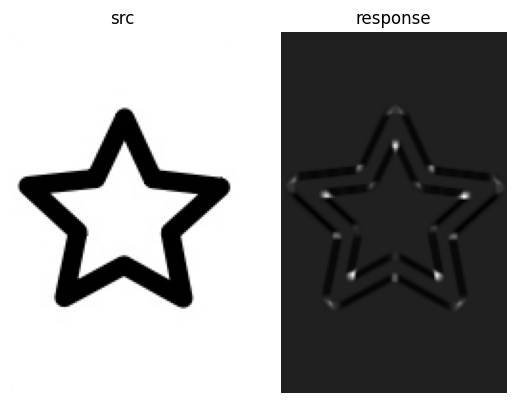

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#1. 실험 이미지 읽기 
#filepath = 'triangle.png' # 'zener_star.jpg' 
filepath = 'zener_star.jpg' 
src = cv2.imread(filepath)

# 변형  
'''
rows, cols, channels = src.shape

# Rotation 변화, Invariant?
M = cv2.getRotationMatrix2D( (cols/2, rows/2),  45, 1.0 )  # center, rotation, scale 
src = cv2.warpAffine( src, M, (cols, rows), borderValue=(255, 255, 255))  # 변형하고 주변을 하얀색으로 채움 

# Scale 변화! invariant?
M = cv2.getRotationMatrix2D( (cols/2, rows/2),  45, 1.5 )  # center, rotation, scale 
src = cv2.warpAffine( src, M, (cols, rows), borderValue=(255, 255, 255))  # 변형하고 주변을 하얀색으로 채움 
'''

gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)

#2 해리스 코너 적용 
bs = 5;  #5
res = cv2.cornerHarris(gray, blockSize=bs, ksize=3, k=0.04)

# visualize 
plt.subplot(1,2,1), plt.imshow(src), plt.axis('off'), plt.title('src')
plt.subplot(1,2,2), plt.imshow(res, cmap='gray'), plt.axis('off'), plt.title('response')

(<Axes: title={'center': 'dst'}>,
 (-0.5, 117.5, 188.5, -0.5),
 Text(0.5, 1.0, 'dst'))

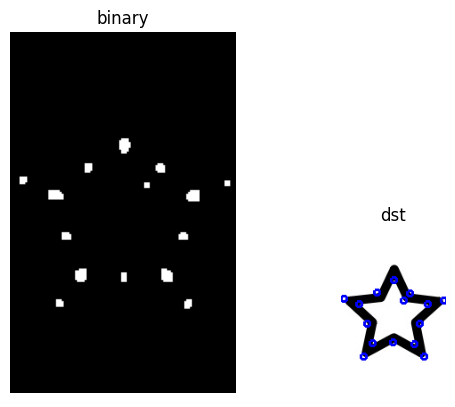

In [6]:
#3. Non-Max Supression 알고리즘 대신 간단하게 Cetroid 를 찾음.
#   TODO: 이진영상에서 연결영역을 찾고, 각 연결 영역 단위로 mask를 만들어서 
#         MinMaxLoc(arr, mask=NULL) 사용하여 위치를 찾으면 될것으로 보임. 
#         관심있는 학생들을 한번 시도해 보길. 
T_harris = 0.01 #0.02
ret, res_bin = cv2.threshold(res, T_harris, 255, cv2.THRESH_BINARY)
res_bin = cv2.dilate(res_bin, None) # 3x3 rect kernel
res_bin = np.uint8(res_bin)
ret, labels, stats, centroids = cv2.connectedComponentsWithStats(res_bin)
#print('centroids.shape=', centroids.shape)
#print('centroids=',centroids)
centroids = np.float32(centroids[1:, :])  # 배경영역제거 

#3. subpixel 검색 
term_crit=(cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS,10, 0.001)
corners = cv2.cornerSubPix(gray, centroids, (5,5), (-1,-1), term_crit)
#print('corners=',corners)

dst = src.copy()
for x, y in corners:    
    cv2.circle(dst, (int(x), int(y)), 3, (0,0,255), 2)
    
plt.subplot(1,2,1), plt.imshow(res_bin, cmap='gray'), plt.axis('off'), plt.title('binary')
plt.subplot(2,2,4), plt.imshow(dst), plt.axis('off'), plt.title('dst')

### 끝